In [7]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load your trained custom CNN model
model = tf.keras.models.load_model("../models/inference.keras")  # Update path

In [8]:
# Automatically find the last convolutional layer
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in model")

In [9]:
# Preprocess the image (Resize only, since model has Rescaling)
def preprocess_image(img_path, image_size):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (image_size, image_size))  # Resize to match model input
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img.astype(np.float32)  # Ensure float32 for TensorFlow

In [10]:
# Grad-CAM++ computation
def grad_cam_plus_plus(model, img_array, layer_name, class_index):
    grad_model = tf.keras.models.Model(
        inputs=[model.input],
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_output)
    grads_squared = tf.square(grads)
    grads_cubed = grads_squared * grads

    # Compute alpha coefficients
    alpha_num = grads_squared
    alpha_den = 2 * grads_squared + tf.reduce_sum(conv_output, axis=(1, 2), keepdims=True) * grads_cubed
    alpha = alpha_num / (alpha_den + 1e-10)

    weights = tf.reduce_sum(alpha * grads, axis=(1, 2))

    # Compute Grad-CAM++ heatmap
    heatmap = tf.reduce_sum(weights * conv_output, axis=-1)
    heatmap = tf.nn.relu(heatmap)

    # Normalize heatmap
    heatmap = heatmap.numpy()
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))
    
    return heatmap[0]

# Overlay heatmap on the image
def overlay_heatmap(img_path, heatmap, alpha=0.5):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))  # Resize to match heatmap
    heatmap = cv2.resize(heatmap, (256, 256))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, alpha, heatmap, 1 - alpha, 0)
    return superimposed_img


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


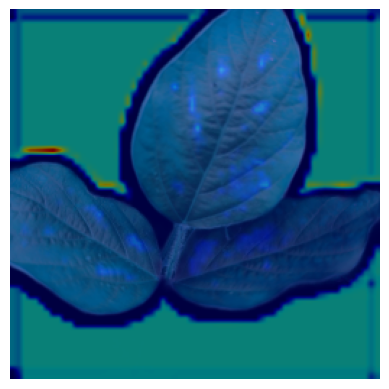

In [5]:
plt.clf()
# Run Grad-CAM++ on a test image
img_path = "../potassium_deficiency_1014.png"
image_size = 256  # Set this to your model’s input size
img_array = preprocess_image(img_path, image_size)

# Get model prediction
predictions = model.predict(img_array)
class_index = np.argmax(predictions)

# Identify the last conv layer automatically
last_conv_layer = find_last_conv_layer(model)

# Generate heatmap
heatmap = grad_cam_plus_plus(model, img_array, last_conv_layer, class_index)

# Overlay heatmap on image
overlayed_img = overlay_heatmap(img_path, heatmap)

# Show the result
plt.imshow(cv2.cvtColor(overlayed_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [6]:
model.summary()

Model: "inference_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,880,356 (64.39 MB)

 Trainable params: 16,880,356 (64.39 MB)

 Non-trainable params: 0 (0.00 B)

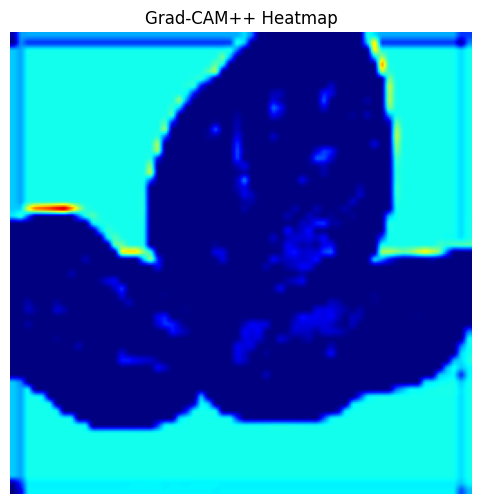

In [11]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Resize heatmap for better visualization
heatmap_resized = cv2.resize(heatmap, (256, 256))

# Convert to 0-255 and apply color map
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

# Convert BGR (OpenCV default) to RGB for matplotlib
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Display the heatmap
plt.figure(figsize=(6, 6))
plt.imshow(heatmap_color)
plt.axis('off')
plt.title("Grad-CAM++ Heatmap")
plt.show()
